In [5]:
import pandas as pd

df = pd.read_csv(r'C:\Users\ibrah\Downloads\Medicare Geographic Variation - by National, State & County\Medicare Geographic Variation - by National, State & County\2023\2014-2023 Medicare Fee-for-Service Geographic Variation Public Use File.csv')

print(df.shape)
print(df.columns.tolist())

C:\Users\ibrah\AppData\Local\Temp\ipykernel_41644\1092619618.py:3: DtypeWarning: Columns (223,224) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\ibrah\Downloads\Medicare Geographic Variation - by National, State & County\Medicare Geographic Variation - by National, State & County\2023\2014-2023 Medicare Fee-for-Service Geographic Variation Public Use File.csv')


(33639, 247)
['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL', 'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_FFS_CNT', 'BENES_MA_CNT', 'MA_PRTCPTN_RATE', 'BENE_AVG_AGE', 'BENE_FEML_PCT', 'BENE_MALE_PCT', 'BENE_RACE_WHT_PCT', 'BENE_RACE_BLACK_PCT', 'BENE_RACE_HSPNC_PCT', 'BENE_RACE_OTHR_PCT', 'BENE_DUAL_PCT', 'BENE_AVG_RISK_SCRE', 'TOT_MDCR_PYMT_AMT', 'TOT_MDCR_STDZD_PYMT_AMT', 'TOT_MDCR_PYMT_PC', 'TOT_MDCR_STDZD_PYMT_PC', 'IP_MDCR_PYMT_AMT', 'IP_MDCR_PYMT_PCT', 'IP_MDCR_PYMT_PC', 'IP_MDCR_PYMT_PER_USER', 'IP_MDCR_STDZD_PYMT_AMT', 'IP_MDCR_STDZD_PYMT_PCT', 'IP_MDCR_STDZD_PYMT_PC', 'IP_MDCR_STDZD_PYMT_PER_USER', 'BENES_IP_CVRD_STAY_CNT', 'BENES_IP_PCT', 'IP_CVRD_STAYS_PER_1000_BENES', 'IP_CVRD_DAYS_PER_1000_BENES', 'ACUTE_HOSP_READMSN_CNT', 'ACUTE_HOSP_READMSN_PCT', 'BENES_ER_VISITS_CNT', 'ER_VISITS_PER_1000_BENES', 'BENES_ER_VISITS_PCT', 'OP_MDCR_PYMT_AMT', 'OP_MDCR_PYMT_PCT', 'OP_MDCR_PYMT_PC', 'OP_MDCR_PYMT_PER_USER', 'OP_MDCR_STDZD_PYMT_AMT', 'OP_MDCR_STDZD

In [6]:
print("Shape:", df.shape)
print("\nFirst 5 columns:", df.columns[:5].tolist())
print("Total columns:", len(df.columns))

Shape: (33639, 247)

First 5 columns: ['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL']
Total columns: 247


In [7]:
# Check geo levels available
print(df['BENE_GEO_LVL'].value_counts())

# Check year range
print("\nYears:", df['YEAR'].unique())

# Check how many county rows we have
county_df = df[df['BENE_GEO_LVL'] == 'County']
print("\nCounty rows:", len(county_df))

BENE_GEO_LVL
County      31959
State        1650
National       30
Name: count, dtype: int64

Years: [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]

County rows: 31959


In [8]:
# Filter to county, 2023 only
county_2023 = df[(df['BENE_GEO_LVL'] == 'County') & (df['YEAR'] == 2023)]

print("Rows:", len(county_2023))

# Find diabetes and depression columns
cols = df.columns.tolist()
diabetes_cols = [c for c in cols if 'DIAB' in c.upper()]
depression_cols = [c for c in cols if 'DEPR' in c.upper()]
spending_cols = [c for c in cols if 'SPEND' in c.upper() or 'PYMT' in c.upper()]

print("\nDiabetes columns:", diabetes_cols)
print("\nDepression columns:", depression_cols)
print("\nSpending columns:", spending_cols[:10])

Rows: 3198

Diabetes columns: []

Depression columns: []

Spending columns: ['TOT_MDCR_PYMT_AMT', 'TOT_MDCR_STDZD_PYMT_AMT', 'TOT_MDCR_PYMT_PC', 'TOT_MDCR_STDZD_PYMT_PC', 'IP_MDCR_PYMT_AMT', 'IP_MDCR_PYMT_PCT', 'IP_MDCR_PYMT_PC', 'IP_MDCR_PYMT_PER_USER', 'IP_MDCR_STDZD_PYMT_AMT', 'IP_MDCR_STDZD_PYMT_PCT']


In [9]:
# Search more broadly for chronic condition columns
chronic_cols = [c for c in cols if any(term in c.upper() for term in 
               ['CHRON', 'CC_', 'COND', 'PREV', 'PCT', 'DIAB', 'DEPR', 'MENTAL', 'ENDOC'])]

print("Chronic/condition columns:", chronic_cols)

Chronic/condition columns: ['BENE_FEML_PCT', 'BENE_MALE_PCT', 'BENE_RACE_WHT_PCT', 'BENE_RACE_BLACK_PCT', 'BENE_RACE_HSPNC_PCT', 'BENE_RACE_OTHR_PCT', 'BENE_DUAL_PCT', 'IP_MDCR_PYMT_PCT', 'IP_MDCR_STDZD_PYMT_PCT', 'BENES_IP_PCT', 'ACUTE_HOSP_READMSN_PCT', 'BENES_ER_VISITS_PCT', 'OP_MDCR_PYMT_PCT', 'OP_MDCR_STDZD_PYMT_PCT', 'BENES_OP_PCT', 'ASC_MDCR_PYMT_PCT', 'ASC_MDCR_STDZD_PYMT_PCT', 'BENES_ASC_PCT', 'SNF_MDCR_PYMT_PCT', 'SNF_MDCR_STDZD_PYMT_PCT', 'BENES_SNF_PCT', 'IRF_MDCR_PYMT_PCT', 'IRF_MDCR_STDZD_PYMT_PCT', 'BENES_IRF_PCT', 'LTCH_MDCR_PYMT_PCT', 'LTCH_MDCR_STDZD_PYMT_PCT', 'BENES_LTCH_PCT', 'HH_MDCR_PYMT_PCT', 'HH_MDCR_STDZD_PYMT_PCT', 'BENES_HH_PCT', 'HOSPC_MDCR_PYMT_PCT', 'HOSPC_MDCR_STDZD_PYMT_PCT', 'BENES_HOSPC_PCT', 'EM_MDCR_PYMT_PCT', 'EM_MDCR_STDZD_PYMT_PCT', 'BENES_EM_PCT', 'PRCDRS_MDCR_PYMT_PCT', 'PRCDRS_MDCR_STDZD_PYMT_PCT', 'BENES_PRCDRS_PCT', 'TESTS_MDCR_PYMT_PCT', 'TESTS_MDCR_STDZD_PYMT_PCT', 'BENES_TESTS_PCT', 'IMGNG_MDCR_PYMT_PCT', 'IMGNG_MDCR_STDZD_PYMT_PCT', 'BEN

In [10]:
for i, col in enumerate(cols):
    print(i, col)

0 YEAR
1 BENE_GEO_LVL
2 BENE_GEO_DESC
3 BENE_GEO_CD
4 BENE_AGE_LVL
5 BENES_TOTAL_CNT
6 BENES_WTH_PTAPTB_CNT
7 BENES_FFS_CNT
8 BENES_MA_CNT
9 MA_PRTCPTN_RATE
10 BENE_AVG_AGE
11 BENE_FEML_PCT
12 BENE_MALE_PCT
13 BENE_RACE_WHT_PCT
14 BENE_RACE_BLACK_PCT
15 BENE_RACE_HSPNC_PCT
16 BENE_RACE_OTHR_PCT
17 BENE_DUAL_PCT
18 BENE_AVG_RISK_SCRE
19 TOT_MDCR_PYMT_AMT
20 TOT_MDCR_STDZD_PYMT_AMT
21 TOT_MDCR_PYMT_PC
22 TOT_MDCR_STDZD_PYMT_PC
23 IP_MDCR_PYMT_AMT
24 IP_MDCR_PYMT_PCT
25 IP_MDCR_PYMT_PC
26 IP_MDCR_PYMT_PER_USER
27 IP_MDCR_STDZD_PYMT_AMT
28 IP_MDCR_STDZD_PYMT_PCT
29 IP_MDCR_STDZD_PYMT_PC
30 IP_MDCR_STDZD_PYMT_PER_USER
31 BENES_IP_CVRD_STAY_CNT
32 BENES_IP_PCT
33 IP_CVRD_STAYS_PER_1000_BENES
34 IP_CVRD_DAYS_PER_1000_BENES
35 ACUTE_HOSP_READMSN_CNT
36 ACUTE_HOSP_READMSN_PCT
37 BENES_ER_VISITS_CNT
38 ER_VISITS_PER_1000_BENES
39 BENES_ER_VISITS_PCT
40 OP_MDCR_PYMT_AMT
41 OP_MDCR_PYMT_PCT
42 OP_MDCR_PYMT_PC
43 OP_MDCR_PYMT_PER_USER
44 OP_MDCR_STDZD_PYMT_AMT
45 OP_MDCR_STDZD_PYMT_PCT
46 OP_MDCR_S

In [11]:
print(county_2023['BENE_AGE_LVL'].value_counts())

BENE_AGE_LVL
All    3198
Name: count, dtype: int64


In [12]:
pqi_cols = [c for c in cols if 'PQI' in c]
print(county_2023[pqi_cols].isnull().sum())
print("\nSample values:")
print(county_2023[pqi_cols].head(3))

PQI03_DBTS_AGE_LT_65                3198
PQI03_DBTS_AGE_65_74                3198
PQI03_DBTS_AGE_GE_75                3198
PQI05_COPD_ASTHMA_AGE_40_64         3198
PQI05_COPD_ASTHMA_AGE_65_74         3198
PQI05_COPD_ASTHMA_AGE_GE_75         3198
PQI07_HYPRTNSN_AGE_LT_65            3198
PQI07_HYPRTNSN_AGE_65_74            3198
PQI07_HYPRTNSN_AGE_GE_75            3198
PQI08_CHF_AGE_LT_65                 3198
PQI08_CHF_AGE_65_74                 3198
PQI08_CHF_AGE_GE_75                 3198
PQI11_BCTRL_PNA_AGE_LT_65           3198
PQI11_BCTRL_PNA_AGE_65_74           3198
PQI11_BCTRL_PNA_AGE_GE_75           3198
PQI12_UTI_AGE_LT_65                 3198
PQI12_UTI_AGE_65_74                 3198
PQI12_UTI_AGE_GE_75                 3198
PQI15_ASTHMA_AGE_LT_40              3198
PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65    3198
PQI16_LWRXTRMTY_AMPUTN_AGE_65_74    3198
PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75    3198
dtype: int64

Sample values:
      PQI03_DBTS_AGE_LT_65 PQI03_DBTS_AGE_65_74 PQI03_DBTS_AGE_GE_75 

In [13]:
# Select our working columns
keep_cols = [
    'BENE_GEO_CD', 'BENE_GEO_DESC',
    'BENE_DUAL_PCT', 'BENE_RACE_BLACK_PCT', 
    'BENE_RACE_HSPNC_PCT', 'BENE_RACE_WHT_PCT',
    'BENE_AVG_RISK_SCRE',
    'BENES_ER_VISITS_PCT', 'ER_VISITS_PER_1000_BENES',
    'ACUTE_HOSP_READMSN_PCT',
    'BENES_HH_PCT', 'FQHC_RHC_VISITS_PER_1000_BENES',
    'TOT_MDCR_STDZD_PYMT_PC', 'IP_MDCR_STDZD_PYMT_PC'
]

working_df = county_2023[keep_cols].copy()
print(working_df.shape)
print("\nNull counts:")
print(working_df.isnull().sum())

(3198, 14)

Null counts:
BENE_GEO_CD                       0
BENE_GEO_DESC                     0
BENE_DUAL_PCT                     0
BENE_RACE_BLACK_PCT               0
BENE_RACE_HSPNC_PCT               0
BENE_RACE_WHT_PCT                 0
BENE_AVG_RISK_SCRE                0
BENES_ER_VISITS_PCT               0
ER_VISITS_PER_1000_BENES          0
ACUTE_HOSP_READMSN_PCT            0
BENES_HH_PCT                      0
FQHC_RHC_VISITS_PER_1000_BENES    0
TOT_MDCR_STDZD_PYMT_PC            0
IP_MDCR_STDZD_PYMT_PC             0
dtype: int64


In [14]:
print(working_df.describe().round(2))

       BENE_GEO_CD
count      3198.00
mean      30411.39
std       15261.98
min        1000.00
25%       18173.50
50%       29178.00
75%       45080.50
max       78030.00


In [15]:
print(working_df.dtypes)

BENE_GEO_CD                       float64
BENE_GEO_DESC                      object
BENE_DUAL_PCT                      object
BENE_RACE_BLACK_PCT                object
BENE_RACE_HSPNC_PCT                object
BENE_RACE_WHT_PCT                  object
BENE_AVG_RISK_SCRE                 object
BENES_ER_VISITS_PCT                object
ER_VISITS_PER_1000_BENES           object
ACUTE_HOSP_READMSN_PCT             object
BENES_HH_PCT                       object
FQHC_RHC_VISITS_PER_1000_BENES     object
TOT_MDCR_STDZD_PYMT_PC             object
IP_MDCR_STDZD_PYMT_PC              object
dtype: object


In [16]:
# Check what unique non-numeric values exist in a few columns
print(working_df['BENE_DUAL_PCT'].unique()[:20])
print(working_df['TOT_MDCR_STDZD_PYMT_PC'].unique()[:20])

['0.2869' '0.3517' '0.2271' '0.6338' '0.2047' '0.25' '0.3539' '0.109'
 '0.4646' '0.1721' '0.2089' '0.251' '0.1719' '0.1713' '0.2076' '0.22'
 '0.7018' '0.442' '0.1959' '0.5484']
['7913.45' '8125.52' '9192.93' '8116.22' '10405.53' '12756.78' '5332.91'
 '5916.78' '14747.37' '7065.32' '11058.37' '10412.02' '9425.84' '9098.6'
 '9887.2' '9366.06' '7960.16' '8876.24' '8731.39' '12995.92']


In [26]:
working_df['BENE_GEO_CD'] = working_df['BENE_GEO_CD'].astype(str)
cols_to_convert = [col for col in working_df.columns
                      if col not in ['BENE_GEO_CD', 'BENE_GEO_DESC']]
working_df[cols_to_convert] = working_df[cols_to_convert].apply(pd.to_numeric, errors = 'coerce')
print(working_df.dtypes)
print('\n the number of nulls')
working_df.isnull().sum()
print(working_df.describe().round(2))

                   
                

BENE_GEO_CD                        object
BENE_GEO_DESC                      object
BENE_DUAL_PCT                     float64
BENE_RACE_BLACK_PCT               float64
BENE_RACE_HSPNC_PCT               float64
BENE_RACE_WHT_PCT                 float64
BENE_AVG_RISK_SCRE                float64
BENES_ER_VISITS_PCT               float64
ER_VISITS_PER_1000_BENES          float64
ACUTE_HOSP_READMSN_PCT            float64
BENES_HH_PCT                      float64
FQHC_RHC_VISITS_PER_1000_BENES    float64
TOT_MDCR_STDZD_PYMT_PC            float64
IP_MDCR_STDZD_PYMT_PC             float64
dtype: object

 the number of nulls
       BENE_DUAL_PCT  BENE_RACE_BLACK_PCT  BENE_RACE_HSPNC_PCT  \
count        3123.00              1797.00              1797.00   
mean            0.16                 0.06                 0.04   
std             0.07                 0.09                 0.07   
min             0.00                 0.00                 0.00   
25%             0.11                 0.01     

In [27]:
outcome_cols = [
    'BENES_ER_VISITS_PCT',
    'ER_VISITS_PER_1000_BENES',
    'ACUTE_HOSP_READMSN_PCT',
    'TOT_MDCR_STDZD_PYMT_PC',
    'IP_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_RISK_SCRE'
]
correlations = working_df[outcome_cols].corrwith(working_df['BENE_DUAL_PCT'])
print((correlations).round(2))

BENES_ER_VISITS_PCT         0.21
ER_VISITS_PER_1000_BENES    0.37
ACUTE_HOSP_READMSN_PCT      0.26
TOT_MDCR_STDZD_PYMT_PC      0.11
IP_MDCR_STDZD_PYMT_PC       0.32
BENE_AVG_RISK_SCRE          0.38
dtype: float64


In [29]:
working_df['DUAL_QUARTILE'] = pd.qcut(
    working_df['BENE_DUAL_PCT'],
    q=4,
    labels = ('low', 'low-mid','high_mid','high')
)
quartile_summary = working_df.groupby('DUAL_QUARTILE', observed = True)[[
    'BENES_ER_VISITS_PCT',
    'ER_VISITS_PER_1000_BENES',
    'ACUTE_HOSP_READMSN_PCT',
    'TOT_MDCR_STDZD_PYMT_PC',
    'IP_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_RISK_SCRE'
]].mean().round(2)
print(quartile_summary)

               BENES_ER_VISITS_PCT  ER_VISITS_PER_1000_BENES  \
DUAL_QUARTILE                                                  
low                           0.28                    533.12   
low-mid                       0.30                    587.12   
high_mid                      0.30                    621.66   
high                          0.31                    666.05   

               ACUTE_HOSP_READMSN_PCT  TOT_MDCR_STDZD_PYMT_PC  \
DUAL_QUARTILE                                                   
low                              0.16                11419.33   
low-mid                          0.16                11646.33   
high_mid                         0.17                11671.92   
high                             0.18                11911.11   

               IP_MDCR_STDZD_PYMT_PC  BENE_AVG_RISK_SCRE  
DUAL_QUARTILE                                             
low                          2467.92                0.90  
low-mid                      2607.73           

In [30]:
#As dual eligibility increases across county quartiles, ER visit intensity grows nearly 25% while overall health burden grows only 12% 
# — suggesting that low income Medicare populations are accessing care through emergency channels at rates disproportionate to their health needs.
low = quartile_summary.loc['low']
high = quartile_summary.loc['high']
pct_change = ((high - low) / low) * 100
print(pct_change)

BENES_ER_VISITS_PCT         10.714286
ER_VISITS_PER_1000_BENES    24.934349
ACUTE_HOSP_READMSN_PCT      12.500000
TOT_MDCR_STDZD_PYMT_PC       4.306557
IP_MDCR_STDZD_PYMT_PC       16.042254
BENE_AVG_RISK_SCRE          12.222222
dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = 'whitegrid', palette = 'muted')
print('Libraries loaded succesfully')

Libraries loaded succesfully


C:\Users\ibrah\AppData\Local\Temp\ipykernel_41644\1568087194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


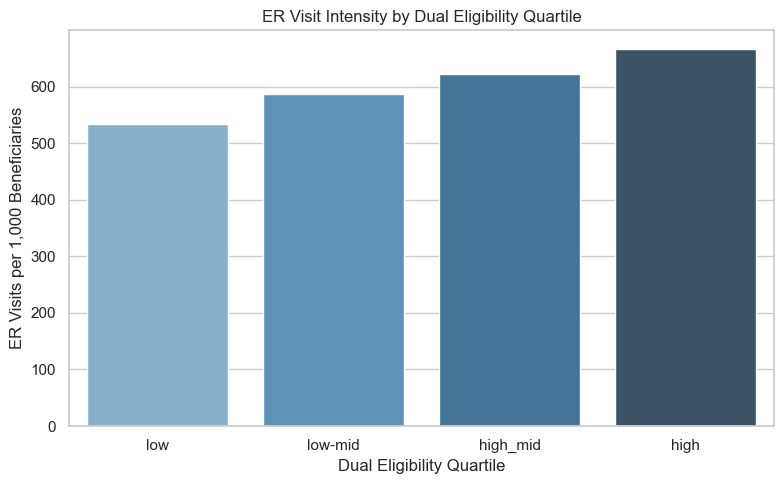

In [35]:
plt.figure(figsize = (8,5))
sns.barplot(
    x = quartile_summary.index,
    y= quartile_summary['ER_VISITS_PER_1000_BENES'],
    palette = 'Blues_d'
)
plt.title('ER Visit Intensity by Dual Eligibility Quartile')
plt.xlabel('Dual Eligibility Quartile')
plt.ylabel('ER Visits per 1,000 Beneficiaries')
plt.tight_layout()
plt.show()


C:\Users\ibrah\AppData\Local\Temp\ipykernel_41644\111765458.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


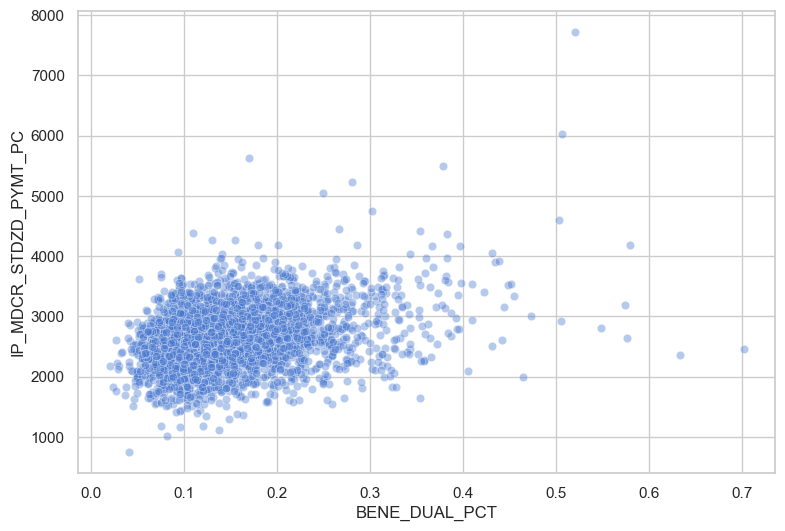

In [42]:
plt.figure(figsize = (9,6))
sns.scatterplot(
    x= 'BENE_DUAL_PCT',
    y= 'IP_MDCR_STDZD_PYMT_PC',
    data = working_df,
    alpha = 0.4,
    palette = 'steelblue'
)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../visuals/chart2_dual_vs_inpatient_trend.png'

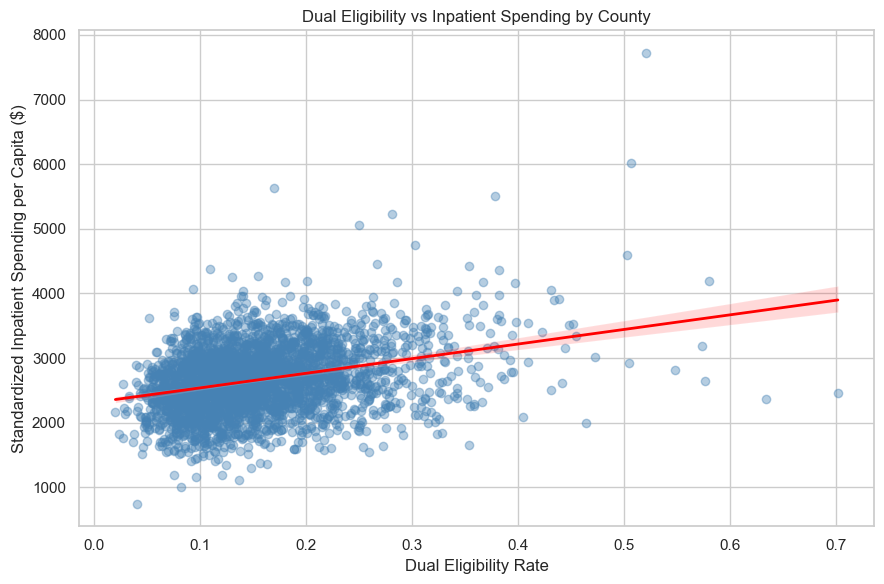

In [43]:
plt.figure(figsize=(9,6))
sns.regplot(
    x='BENE_DUAL_PCT',
    y='IP_MDCR_STDZD_PYMT_PC',
    data=working_df,
    scatter_kws={'alpha':0.4, 'color':'steelblue'},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Dual Eligibility vs Inpatient Spending by County')
plt.xlabel('Dual Eligibility Rate')
plt.ylabel('Standardized Inpatient Spending per Capita ($)')
plt.tight_layout()
plt.show()

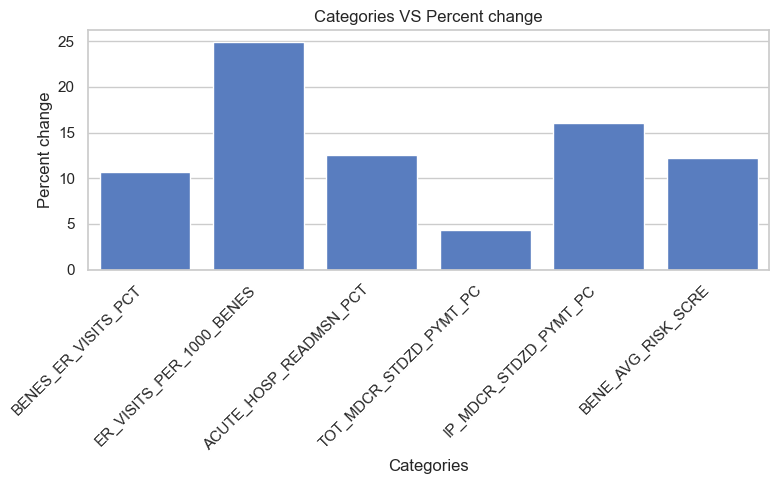

In [47]:
plt.figure(figsize =(8,5))
sns.barplot(
    x = pct_change.index,
    y = pct_change   
)
plt.title('Percent Change in Outcomes from Low to High Dual Eligibility Quartile')
plt.xlabel('Categories')
plt.ylabel('Percent change')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()